In [1]:
import torch
import pandas as pd
import numpy as np
from torch import nn
import matplotlib.pyplot as plt
from torchvision import transforms, datasets

In [2]:
from torch.utils.data import DataLoader

In [3]:
from pathlib import Path

In [4]:
data_path = Path("data/")

In [5]:
dataset_path = data_path / "fish"

In [6]:
dataset_path

WindowsPath('data/fish')

In [7]:
import os

In [8]:
import os

image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".gif", ".tif", ".tiff")

image_paths = []
labels = []

for label in os.listdir(dataset_path):

    class_path = os.path.join(dataset_path, label)

    if not os.path.isdir(class_path):
        continue

    # Gizli klasörleri atla
    if label.startswith("."):
        continue

    for image_name in os.listdir(class_path):

        image_path = os.path.join(class_path, image_name)

        # Sadece resim dosyalarını al
        if os.path.isfile(image_path) and image_name.lower().endswith(image_extensions):
            image_paths.append(image_path)
            labels.append(label)

In [9]:
print(image_paths[:5])

['data\\fish\\Bete\\Copy of Copy of FB_IMG_1747057306318.jpg', 'data\\fish\\Bete\\Copy of Copy of FB_IMG_1747057307989.jpg', 'data\\fish\\Bete\\Copy of Copy of FB_IMG_1747057310245.jpg', 'data\\fish\\Bete\\Copy of Copy of FB_IMG_1747057452605.jpg', 'data\\fish\\Bete\\Copy of Copy of FB_IMG_1747057455194.jpg']


In [10]:
print(sorted(set(labels)))

['Bete', 'Cray', 'Discuss', 'Gold', 'Guppy', 'Oscar']


In [11]:
from sklearn.model_selection import train_test_split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(image_paths,labels,test_size=0.15,
                                                    random_state=42,
                                                    stratify=labels,
                                                    shuffle=True)

In [13]:
X_train

['data\\fish\\Cray\\Copy of Copy of FB_IMG_1747318600606.jpg',
 'data\\fish\\Bete\\Copy of Copy of FB_IMG_1747058260602.jpg',
 'data\\fish\\Gold\\Copy of Copy of Picsart_25-07-02_21-02-20-101.jpg',
 'data\\fish\\Bete\\Copy of Copy of FB_IMG_1747058426225.jpg',
 'data\\fish\\Discuss\\Copy of Copy of FB_IMG_1747575300132 (1).jpg',
 'data\\fish\\Gold\\Copy of Copy of Picsart_25-07-02_20-36-46-708.jpg',
 'data\\fish\\Gold\\Copy of Copy of Picsart_25-07-02_20-11-54-067.jpg',
 'data\\fish\\Guppy\\Copy of Copy of FB_IMG_1747145167086 (1).jpg',
 'data\\fish\\Bete\\Copy of Copy of FB_IMG_1747058373991.jpg',
 'data\\fish\\Discuss\\Copy of Copy of Picsart_25-06-30_10-22-02-339.jpg',
 'data\\fish\\Discuss\\Copy of Copy of Picsart_25-06-30_10-28-44-249.jpg',
 'data\\fish\\Discuss\\Copy of Copy of FB_IMG_1747574897664.jpg',
 'data\\fish\\Guppy\\Copy of Copy of Picsart_25-07-02_19-37-21-927.jpg',
 'data\\fish\\Oscar\\Copy of Copy of Picsart_25-06-21_21-55-33-264.png',
 'data\\fish\\Gold\\Copy of Copy

In [14]:
from torch.utils.data import Dataset
from PIL import Image

class FishDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

        self.classes = sorted(set(labels))
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = self.class_to_idx[self.labels[idx]]

        return image, label

In [15]:
def calculate_dataset_statistics(dataset,
                                 batch_size=32,
                                 num_workers=0):

    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers
    )

    mean = torch.zeros(3)
    std = torch.zeros(3)
    total_images = 0

    for images, _ in dataloader:

        images = images.view(images.size(0), images.size(1), -1)

        mean += images.mean(dim=2).sum(dim=0)
        std += images.std(dim=2).sum(dim=0)

        total_images += images.size(0)

    mean /= total_images
    std /= total_images

    return mean, std

In [16]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225])
])

In [17]:
train_dataset = FishDataset(
    X_train,
    y_train,
    transform=train_transform
)

In [18]:
test_dataset = FishDataset(
    X_test,
    y_test,
    transform=test_transform
)

In [19]:
mean, std = calculate_dataset_statistics(train_dataset)

print(mean)
print(std)

tensor([-1.3773, -1.4352, -1.2969])
tensor([1.1772, 0.9919, 0.8993])


In [20]:
mean, std = calculate_dataset_statistics(test_dataset)

print(mean)
print(std)

tensor([-1.4391, -1.5194, -1.3949])
tensor([1.2318, 1.0090, 0.8893])


In [21]:
import os

print(os.listdir("data/fish"))
print(os.listdir("data/fish/Bete"))

['.ipynb_checkpoints', 'Bete', 'bete.jpg', 'Cray', 'cray.jpg', 'discus.jpg', 'Discuss', 'Gold', 'gold.jpg', 'Guppy', 'guppy.jpg', 'Oscar', 'oscar.jpg']
['.ipynb_checkpoints', 'Copy of Copy of FB_IMG_1747057306318.jpg', 'Copy of Copy of FB_IMG_1747057307989.jpg', 'Copy of Copy of FB_IMG_1747057310245.jpg', 'Copy of Copy of FB_IMG_1747057452605.jpg', 'Copy of Copy of FB_IMG_1747057455194.jpg', 'Copy of Copy of FB_IMG_1747057459051.jpg', 'Copy of Copy of FB_IMG_1747057462460.jpg', 'Copy of Copy of FB_IMG_1747057473052.jpg', 'Copy of Copy of FB_IMG_1747057475122.jpg', 'Copy of Copy of FB_IMG_1747057477034.jpg', 'Copy of Copy of FB_IMG_1747057478917.jpg', 'Copy of Copy of FB_IMG_1747057481535.jpg', 'Copy of Copy of FB_IMG_1747057485164.jpg', 'Copy of Copy of FB_IMG_1747057488739.jpg', 'Copy of Copy of FB_IMG_1747057490744.jpg', 'Copy of Copy of FB_IMG_1747057493033.jpg', 'Copy of Copy of FB_IMG_1747057495256.jpg', 'Copy of Copy of FB_IMG_1747057497426.jpg', 'Copy of Copy of FB_IMG_174705751

In [22]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225])
    
])

In [23]:
from torch.utils.data import DataLoader

NUM_WORKERS = os.cpu_count()

def create_dataloaders(
    X_train,
    y_train,
    X_test,
    y_test,
    transform,
    batch_size,
    num_workers=0
):

    train_dataset = FishDataset(
        X_train,
        y_train,
        transform=transform
    )

    test_dataset = FishDataset(
        X_test,
        y_test,
        transform=transform
    )

    class_names = train_dataset.classes

    train_dataloader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        pin_memory=True
    )

    test_dataloader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=True
    )

    return train_dataloader, test_dataloader, class_names

In [24]:
train_loader, test_loader, class_names = create_dataloaders(
    X_train,
    y_train,
    X_test,
    y_test,
    transform=transform,
    batch_size=32
)

In [25]:
train_loader

In [26]:
test_loader

In [27]:
train_dataset.classes

['Bete', 'Cray', 'Discuss', 'Gold', 'Guppy', 'Oscar']

In [28]:
class_names = train_dataset.classes

In [29]:
len(class_names)

6

In [30]:
import torchvision

In [31]:
weights = torchvision.models.ConvNeXt_Tiny_Weights.DEFAULT

In [32]:
weights

ConvNeXt_Tiny_Weights.IMAGENET1K_V1

In [33]:
auto_transforms = weights.transforms()

In [34]:
auto_transforms

ImageClassification(
    crop_size=[224]
    resize_size=[236]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [35]:
train_dataloader, test_dataloader, class_names = create_dataloaders(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    transform=auto_transforms,
    batch_size=32
)

In [36]:
torch.cuda.is_available()

True

In [37]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [38]:
device

'cuda'

In [39]:
model = torchvision.models.convnext_tiny(weights=weights).to(device)

In [40]:
model

ConvNeXt(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
    )
    (1): Sequential(
      (0): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=96, out_features=384, bias=True)
          (4): GELU(approximate='none')
          (5): Linear(in_features=384, out_features=96, bias=True)
          (6): Permute()
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=

In [41]:
from torchinfo import summary

In [42]:
summary(model=model,
        input_size=(32,3,224,224),
        col_names = ["input_size","output_size",
"num_params",
"trainable",])

Layer (type:depth-idx)                        Input Shape               Output Shape              Param #                   Trainable
ConvNeXt                                      [32, 3, 224, 224]         [32, 1000]                --                        True
├─Sequential: 1-1                             [32, 3, 224, 224]         [32, 768, 7, 7]           --                        True
│    └─Conv2dNormActivation: 2-1              [32, 3, 224, 224]         [32, 96, 56, 56]          --                        True
│    │    └─Conv2d: 3-1                       [32, 3, 224, 224]         [32, 96, 56, 56]          4,704                     True
│    │    └─LayerNorm2d: 3-2                  [32, 96, 56, 56]          [32, 96, 56, 56]          192                       True
│    └─Sequential: 2-2                        [32, 96, 56, 56]          [32, 96, 56, 56]          --                        True
│    │    └─CNBlock: 3-3                      [32, 96, 56, 56]          [32, 96, 56, 56]    

In [43]:
for param in model.features.parameters():
  param.requires_grad = False

In [44]:
summary(model=model,
        input_size=(32,3,224,224),
        col_names = ["input_size","output_size",
"num_params",
"trainable",])

Layer (type:depth-idx)                        Input Shape               Output Shape              Param #                   Trainable
ConvNeXt                                      [32, 3, 224, 224]         [32, 1000]                --                        Partial
├─Sequential: 1-1                             [32, 3, 224, 224]         [32, 768, 7, 7]           --                        False
│    └─Conv2dNormActivation: 2-1              [32, 3, 224, 224]         [32, 96, 56, 56]          --                        False
│    │    └─Conv2d: 3-1                       [32, 3, 224, 224]         [32, 96, 56, 56]          (4,704)                   False
│    │    └─LayerNorm2d: 3-2                  [32, 96, 56, 56]          [32, 96, 56, 56]          (192)                     False
│    └─Sequential: 2-2                        [32, 96, 56, 56]          [32, 96, 56, 56]          --                        False
│    │    └─CNBlock: 3-3                      [32, 96, 56, 56]          [32, 96, 56,

In [45]:
len(class_names)

6

In [46]:
output_shape = len(class_names)

In [47]:
import torch.nn as nn

model.classifier[2] = nn.Linear(
    in_features=768,
    out_features=output_shape,
    bias=True
)

In [48]:
summary(model=model,
        input_size=(32,3,224,224),
        col_names = ["input_size","output_size",
"num_params",
"trainable",])

Layer (type:depth-idx)                        Input Shape               Output Shape              Param #                   Trainable
ConvNeXt                                      [32, 3, 224, 224]         [32, 6]                   --                        Partial
├─Sequential: 1-1                             [32, 3, 224, 224]         [32, 768, 7, 7]           --                        False
│    └─Conv2dNormActivation: 2-1              [32, 3, 224, 224]         [32, 96, 56, 56]          --                        False
│    │    └─Conv2d: 3-1                       [32, 3, 224, 224]         [32, 96, 56, 56]          (4,704)                   False
│    │    └─LayerNorm2d: 3-2                  [32, 96, 56, 56]          [32, 96, 56, 56]          (192)                     False
│    └─Sequential: 2-2                        [32, 96, 56, 56]          [32, 96, 56, 56]          --                        False
│    │    └─CNBlock: 3-3                      [32, 96, 56, 56]          [32, 96, 56,

In [49]:
model.classifier = nn.Sequential(
    model.classifier[0],      # LayerNorm2d
    model.classifier[1],      # Flatten
    nn.Dropout(p=0.2),
    nn.Linear(
        model.classifier[2].in_features,
        output_shape
    )
)

In [50]:
summary(model=model,
        input_size=(32,3,224,224),
        col_names = ["input_size","output_size",
"num_params",
"trainable",])

Layer (type:depth-idx)                        Input Shape               Output Shape              Param #                   Trainable
ConvNeXt                                      [32, 3, 224, 224]         [32, 6]                   --                        Partial
├─Sequential: 1-1                             [32, 3, 224, 224]         [32, 768, 7, 7]           --                        False
│    └─Conv2dNormActivation: 2-1              [32, 3, 224, 224]         [32, 96, 56, 56]          --                        False
│    │    └─Conv2d: 3-1                       [32, 3, 224, 224]         [32, 96, 56, 56]          (4,704)                   False
│    │    └─LayerNorm2d: 3-2                  [32, 96, 56, 56]          [32, 96, 56, 56]          (192)                     False
│    └─Sequential: 2-2                        [32, 96, 56, 56]          [32, 96, 56, 56]          --                        False
│    │    └─CNBlock: 3-3                      [32, 96, 56, 56]          [32, 96, 56,

In [51]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

In [52]:
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               device : torch.device):
    # Put model in train mode
    model.train()

    # Setup train loss and train accuracy values
    train_loss, train_acc = 0, 0

    # Loop through data loader data batches
    for batch, (X, y) in enumerate(dataloader):

        X = X.to(device)
        y = y.to(device)

        # 1. Forward pass
        y_pred = model(X)

        # 2. Calculate  and accumulate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

        # Calculate and accumulate accuracy metrics across all batches
        y_pred_class = y_pred.argmax(dim=1)
        train_acc += (y_pred_class == y).sum().item() / len(y_pred)

    # Adjust metrics to get average loss and accuracy per batch
    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    return train_loss, train_acc


def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              device : torch.device):
    # Put model in eval mode
    model.eval()

    # Setup test loss and test accuracy values
    test_loss, test_acc = 0, 0

    # Turn on inference context manager
    with torch.inference_mode():
        # Loop through DataLoader batches
        for batch, (X, y) in enumerate(dataloader):

            X = X.to(device)
            y = y.to(device)
            # 1. Forward pass
            test_pred_logits = model(X)

            # 2. Calculate and accumulate loss
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()

            # Calculate and accumulate accuracy
            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += ((test_pred_labels == y).sum().item() / len(test_pred_labels))

    # Adjust metrics to get average loss and accuracy per batch
    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)
    return test_loss, test_acc


def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          device : torch.device,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          epochs: int = 5):
    # 2. Create empty results dictionary
    results = {"train_loss": [],
               "train_acc": [],
               "test_loss": [],
               "test_acc": []
               }

    # 3. Loop through training and testing steps for a number of epochs
    for epoch in range(epochs):
        train_loss, train_acc = train_step(model=model,
                                           dataloader=train_dataloader,
                                           loss_fn=loss_fn,
                                           optimizer=optimizer,
                                           device = device)
        test_loss, test_acc = test_step(model=model,
                                        dataloader=test_dataloader,
                                        loss_fn=loss_fn,
                                        device = device)

        # 4. Print out what's happening
        print(
            f"Epoch: {epoch + 1} | "
            f"train_loss: {train_loss:.4f} | "
            f"train_acc: {train_acc:.4f} | "
            f"test_loss: {test_loss:.4f} | "
            f"test_acc: {test_acc:.4f}"
        )

        # 5. Update results dictionary
        # Ensure all data is moved to CPU and converted to float for storage
        results["train_loss"].append(train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss)
        results["train_acc"].append(train_acc.item() if isinstance(train_acc, torch.Tensor) else train_acc)
        results["test_loss"].append(test_loss.item() if isinstance(test_loss, torch.Tensor) else test_loss)
        results["test_acc"].append(test_acc.item() if isinstance(test_acc, torch.Tensor) else test_acc)

    # 6. Return the filled results at the end of the epochs
    return results

In [53]:
results = train(model=model,
                train_dataloader=train_dataloader,
                test_dataloader=test_dataloader,
                optimizer = optimizer,
                loss_fn = loss_fn,
                device=device,
                epochs=10)

Epoch: 1 | train_loss: 1.7461 | train_acc: 0.3211 | test_loss: 1.5954 | test_acc: 0.4915
Epoch: 2 | train_loss: 1.5260 | train_acc: 0.5402 | test_loss: 1.3836 | test_acc: 0.6895
Epoch: 3 | train_loss: 1.3333 | train_acc: 0.6918 | test_loss: 1.2107 | test_acc: 0.7680
Epoch: 4 | train_loss: 1.1849 | train_acc: 0.7624 | test_loss: 1.0682 | test_acc: 0.8135
Epoch: 5 | train_loss: 1.0625 | train_acc: 0.8009 | test_loss: 0.9500 | test_acc: 0.8402
Epoch: 6 | train_loss: 0.9371 | train_acc: 0.8425 | test_loss: 0.8512 | test_acc: 0.8590
Epoch: 7 | train_loss: 0.8567 | train_acc: 0.8771 | test_loss: 0.7674 | test_acc: 0.8732
Epoch: 8 | train_loss: 0.7794 | train_acc: 0.8877 | test_loss: 0.6984 | test_acc: 0.8732
Epoch: 9 | train_loss: 0.6980 | train_acc: 0.9062 | test_loss: 0.6393 | test_acc: 0.8858
Epoch: 10 | train_loss: 0.6537 | train_acc: 0.9096 | test_loss: 0.5885 | test_acc: 0.8982


In [54]:
image, label = train_dataset[0]

print(image.shape)
print(label)

torch.Size([3, 224, 224])
1


In [55]:
for images, labels in train_dataloader:
    print(images.shape)
    print(labels.shape)
    break

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [56]:
from PIL import Image

In [57]:
from typing import List, Tuple

In [58]:
def transform_predict(model: nn.Module,
                      image_path: str,
                      class_names: List[str],
                      image_size: Tuple[int,int] = (224,224),
                      transform: torchvision.transforms = None,
                      device: torch.device = device):
    img = Image.open(image_path).convert("RGB")

    if transform is not None:
        image_transform = transform
    else:
        image_transform = transforms.Compose([
            transforms.Resize(image_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225])
        ])

    # Bu blok artık if/else'in DIŞINDA, her durumda çalışır
    model.to(device)
    model.eval()
    with torch.inference_mode():
        transformed_image = image_transform(img).unsqueeze(dim=0)
        target_image_pred = model(transformed_image.to(device))

    target_image_pred_probs = torch.softmax(target_image_pred, dim=1)
    target_image_pred_label = torch.argmax(target_image_pred_probs, dim=1)

    plt.figure()
    plt.imshow(img)
    plt.title(f"Pred: {class_names[target_image_pred_label]}, Prob: {target_image_pred_probs.max():.3f}")
    plt.axis("off")

In [59]:
custom_image_path = dataset_path / "oscar.jpg"

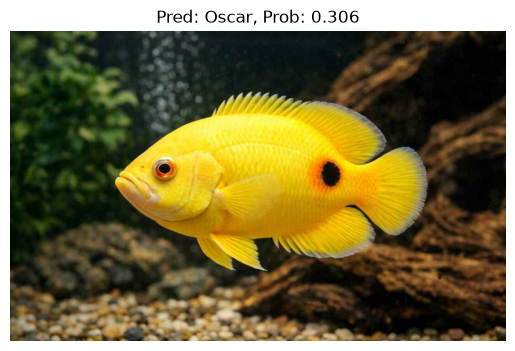

In [60]:
transform_predict(model, custom_image_path, class_names, transform=auto_transforms)

In [61]:
custom_image_path2 = dataset_path / "guppy.jpg"

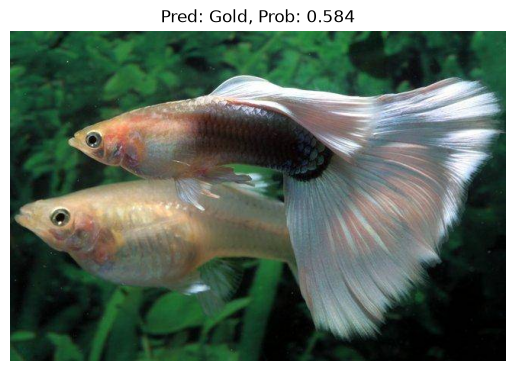

In [62]:
transform_predict(model, custom_image_path2, class_names, transform=auto_transforms)

In [63]:
custom_image_path3 = dataset_path / "gold.jpg"

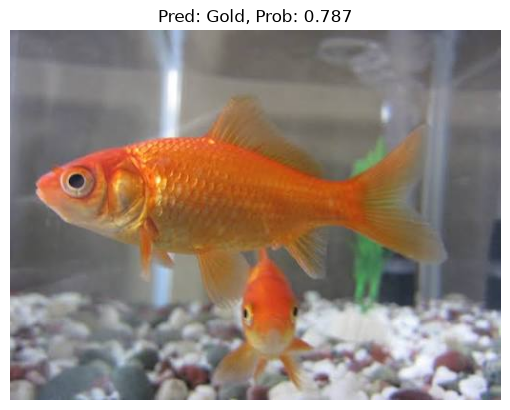

In [64]:
transform_predict(model, custom_image_path3, class_names, transform=auto_transforms)

In [65]:
custom_image_path4 = dataset_path / "discus.jpg"

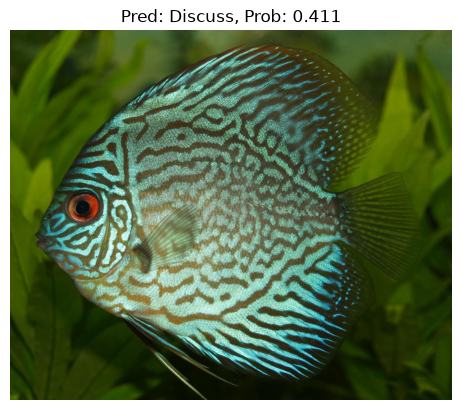

In [66]:
transform_predict(model, custom_image_path4, class_names, transform=auto_transforms)

In [67]:
custom_image_path5 = dataset_path / "cray.jpg"

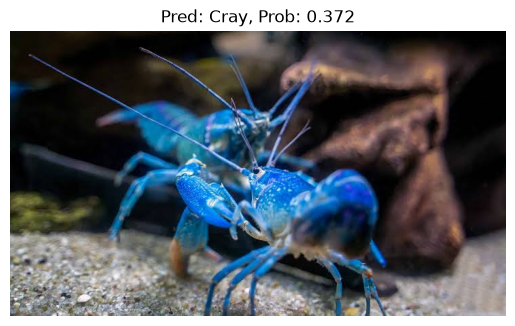

In [68]:
transform_predict(model, custom_image_path5, class_names, transform=auto_transforms)

In [69]:
custom_image_path6 = dataset_path / "bete.jpg"

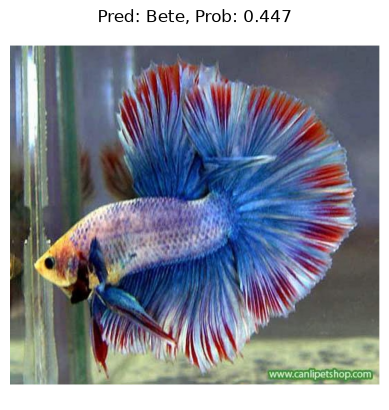

In [70]:
transform_predict(model, custom_image_path6, class_names, transform=auto_transforms)

In [71]:
auto_transforms

ImageClassification(
    crop_size=[224]
    resize_size=[236]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)